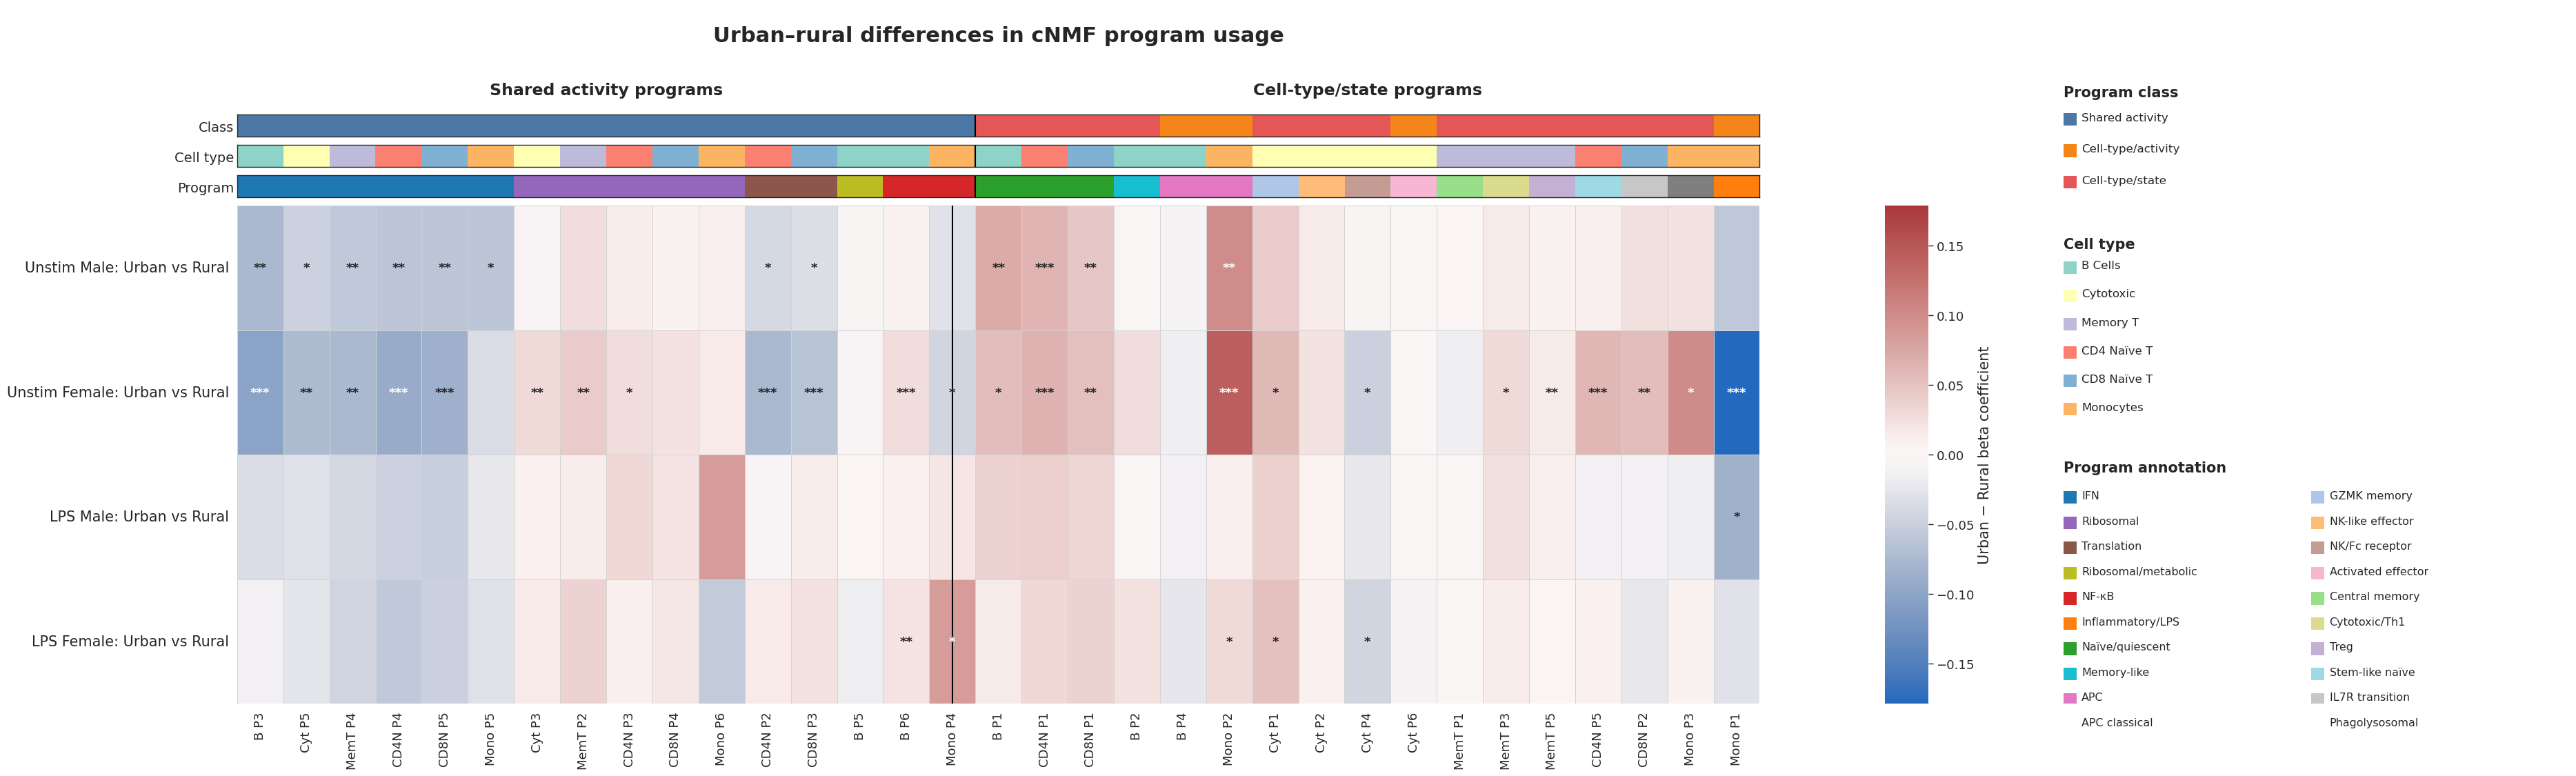

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec

# =========================================================
# 0. SETTINGS
# =========================================================

file_path = "cNMF_Annotation_Celltype.xlsx"
output_prefix = "cNMF_program_usage_heatmap_FINAL"

coef_col = "Program Usage Urban - Rural Beta Coefficient"
padj_col = "FDR-padj_BH"
condition_col = "Sub-group"

contrast_order = [
    "Unstim Male: Urban vs Rural",
    "Unstim Female: Urban vs Rural",
    "LPS Male: Urban vs Rural",
    "LPS Female: Urban vs Rural"
]

contrast_map = {
    "Unstim-Male-Urban": "Unstim Male: Urban vs Rural",
    "Unstim-Female-Urban": "Unstim Female: Urban vs Rural",
    "LPS-Male-Urban": "LPS Male: Urban vs Rural",
    "LPS-Female-Urban": "LPS Female: Urban vs Rural",
    "Unsitm-Male-Urban": "Unstim Male: Urban vs Rural",
    "Unsitm-Female-Urban": "Unstim Female: Urban vs Rural"
}

keep_conditions = [
    "Unstim-Male-Urban",
    "Unstim-Female-Urban",
    "LPS-Male-Urban",
    "LPS-Female-Urban"
]

# =========================================================
# 1. READ EXCEL AND FIX HEADER
# =========================================================

raw = pd.read_excel(file_path, header=None)

header_row = None
for i in range(raw.shape[0]):
    row = raw.iloc[i].astype(str).str.strip().tolist()
    if "Celltype" in row and "Gene Program" in row:
        header_row = i
        break

if header_row is None:
    raise ValueError("Could not find the header row containing Celltype and Gene Program.")

headers = raw.iloc[header_row].astype(str).str.strip().tolist()
subheaders = raw.iloc[header_row + 1].astype(str).str.strip().tolist()

clean_headers = []
for h, sh in zip(headers, subheaders):
    if h in ["", "nan", "None"]:
        clean_headers.append(sh)
    elif h in ["Cell Type Programs", "Activity Programs"] and sh not in ["", "nan", "None"]:
        clean_headers.append(sh)
    else:
        clean_headers.append(h)

df = raw.iloc[header_row + 2:].copy()
df.columns = clean_headers

df = df.dropna(axis=0, how="all")
df = df.dropna(axis=1, how="all")
df.columns = df.columns.astype(str).str.strip()
df = df.loc[:, df.columns != "nan"]
df = df.loc[:, ~df.columns.duplicated()].copy()

# Forward-fill merged annotation cells
annotation_cols = [
    "Celltype",
    "Gene Program",
    "ProgramDefining Genes",
    "Final Program Annotation",
    "Program Class"
]

df[annotation_cols] = df[annotation_cols].ffill()

# =========================================================
# 2. PREPARE HEATMAP DATA
# =========================================================

df["Condition"] = (
    df[condition_col]
    .astype(str)
    .str.strip()
    .str.replace("Unsitm", "Unstim", regex=False)
)

df_hm = df[df["Condition"].isin(keep_conditions)].copy()

df_hm[coef_col] = pd.to_numeric(df_hm[coef_col], errors="coerce")
df_hm[padj_col] = pd.to_numeric(df_hm[padj_col], errors="coerce")
df_hm = df_hm.dropna(subset=[coef_col]).copy()

df_hm["Contrast"] = df_hm["Condition"].map(contrast_map)

# Short program IDs
celltype_short_map = {
    "B Cells": "B",
    "Cytotoxic": "Cyt",
    "Memory T": "MemT",
    "CD4 Naïve T": "CD4N",
    "CD8 Naïve T": "CD8N",
    "Monocytes": "Mono"
}

df_hm["Celltype_short"] = df_hm["Celltype"].replace(celltype_short_map)

df_hm["Program_Label"] = (
    df_hm["Celltype_short"].astype(str).str.strip()
    + " "
    + df_hm["Gene Program"].astype(str).str.strip()
)

# =========================================================
# 3. BIOLOGICAL PROGRAM ANNOTATION
# =========================================================

subgroup_map = {
    "B P1": "Naïve/quiescent",
    "B P2": "Memory-like",
    "B P3": "IFN",
    "B P4": "APC",
    "B P5": "Ribosomal/metabolic",
    "B P6": "NF-κB",

    "Cyt P1": "GZMK memory",
    "Cyt P2": "NK-like effector",
    "Cyt P3": "Ribosomal",
    "Cyt P4": "NK/Fc receptor",
    "Cyt P5": "IFN",
    "Cyt P6": "Activated effector",

    "MemT P1": "Central memory",
    "MemT P2": "Ribosomal",
    "MemT P3": "Cytotoxic/Th1",
    "MemT P4": "IFN",
    "MemT P5": "Treg",

    "CD4N P1": "Naïve/quiescent",
    "CD4N P2": "Translation",
    "CD4N P3": "Ribosomal",
    "CD4N P4": "IFN",
    "CD4N P5": "Stem-like naïve",

    "CD8N P1": "Naïve/quiescent",
    "CD8N P2": "IL7R transition",
    "CD8N P3": "Translation",
    "CD8N P4": "Ribosomal",
    "CD8N P5": "IFN",

    "Mono P1": "Inflammatory/LPS",
    "Mono P2": "APC classical",
    "Mono P3": "Phagolysosomal",
    "Mono P4": "NF-κB",
    "Mono P5": "IFN",
    "Mono P6": "Ribosomal"
}

df_hm["Biological_Subgroup"] = df_hm["Program_Label"].map(subgroup_map)

# Force Mono P6 into shared ribosomal activity
df_hm.loc[df_hm["Program_Label"] == "Mono P6", "Program Class"] = "Shared activity"

# =========================================================
# 4. ORDER PROGRAMS
# =========================================================

class_order = {
    "Shared activity": 0,
    "Shared/cell-type activity": 0,
    "Cell-type/activity": 1,
    "Cell-type/state": 1
}

celltype_order = {
    "B Cells": 0,
    "Cytotoxic": 1,
    "Memory T": 2,
    "CD4 Naïve T": 3,
    "CD8 Naïve T": 4,
    "Monocytes": 5
}

shared_subgroup_order = {
    "IFN": 0,
    "Ribosomal": 1,
    "Translation": 2,
    "Ribosomal/metabolic": 3,
    "NF-κB": 4,
    "Inflammatory/LPS": 5
}

cell_specific_subgroup_order = {
    "Naïve/quiescent": 0,
    "Memory-like": 1,
    "APC": 2,
    "APC classical": 3,
    "GZMK memory": 4,
    "NK-like effector": 5,
    "NK/Fc receptor": 6,
    "Activated effector": 7,
    "Central memory": 8,
    "Cytotoxic/Th1": 9,
    "Treg": 10,
    "Stem-like naïve": 11,
    "IL7R transition": 12,
    "Phagolysosomal": 13
}

df_hm["Program_Class_Order"] = df_hm["Program Class"].map(class_order).fillna(1)
df_hm["Celltype_Order"] = df_hm["Celltype"].map(celltype_order).fillna(99)

df_hm["Program_Number"] = (
    df_hm["Gene Program"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

def get_subgroup_order(row):
    if row["Program_Class_Order"] == 0:
        return shared_subgroup_order.get(row["Biological_Subgroup"], 50)
    else:
        return cell_specific_subgroup_order.get(row["Biological_Subgroup"], 50)

df_hm["Subgroup_Order"] = df_hm.apply(get_subgroup_order, axis=1)

program_order = (
    df_hm[
        [
            "Program_Label",
            "Program_Class_Order",
            "Subgroup_Order",
            "Celltype_Order",
            "Program_Number"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "Program_Class_Order",
            "Subgroup_Order",
            "Celltype_Order",
            "Program_Number"
        ]
    )
    ["Program_Label"]
    .tolist()
)

# =========================================================
# 5. MATRICES
# =========================================================

heatmap_df = df_hm.pivot_table(
    index="Contrast",
    columns="Program_Label",
    values=coef_col,
    aggfunc="first"
).reindex(index=contrast_order, columns=program_order)

def p_to_star(p):
    if pd.isna(p):
        return ""
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

df_hm["stars"] = df_hm[padj_col].apply(p_to_star)

stars_df = df_hm.pivot_table(
    index="Contrast",
    columns="Program_Label",
    values="stars",
    aggfunc="first"
).reindex(index=contrast_order, columns=program_order)

col_meta = (
    df_hm[
        [
            "Program_Label",
            "Program Class",
            "Celltype",
            "Biological_Subgroup",
            "Program_Class_Order"
        ]
    ]
    .drop_duplicates()
    .set_index("Program_Label")
    .reindex(program_order)
)

# =========================================================
# 6. COLORS
# =========================================================

program_class_palette = {
    "Shared activity": "#4C78A8",
    "Shared/cell-type activity": "#72B7B2",
    "Cell-type/activity": "#F58518",
    "Cell-type/state": "#E45756"
}

celltype_palette = {
    "B Cells": "#8DD3C7",
    "Cytotoxic": "#FFFFB3",
    "Memory T": "#BEBADA",
    "CD4 Naïve T": "#FB8072",
    "CD8 Naïve T": "#80B1D3",
    "Monocytes": "#FDB462"
}

subgroup_palette = {
    "IFN": "#1F77B4",
    "Ribosomal": "#9467BD",
    "Translation": "#8C564B",
    "Ribosomal/metabolic": "#BCBD22",
    "NF-κB": "#D62728",
    "Inflammatory/LPS": "#FF7F0E",
    "Naïve/quiescent": "#2CA02C",
    "Memory-like": "#17BECF",
    "APC": "#E377C2",
    "APC classical": "#E377C2",
    "GZMK memory": "#AEC7E8",
    "NK-like effector": "#FFBB78",
    "NK/Fc receptor": "#C49C94",
    "Activated effector": "#F7B6D2",
    "Central memory": "#98DF8A",
    "Cytotoxic/Th1": "#DBDB8D",
    "Treg": "#C5B0D5",
    "Stem-like naïve": "#9EDAE5",
    "IL7R transition": "#C7C7C7",
    "Phagolysosomal": "#7F7F7F"
}

def make_color_bar(series, palette):
    colors = series.map(palette).fillna("#FFFFFF").tolist()
    unique_colors = list(dict.fromkeys(colors))
    color_to_int = {c: i for i, c in enumerate(unique_colors)}
    bar = np.array([[color_to_int[c] for c in colors]])
    cmap = ListedColormap(unique_colors)
    return bar, cmap

class_bar, class_cmap = make_color_bar(col_meta["Program Class"], program_class_palette)
celltype_bar, celltype_cmap = make_color_bar(col_meta["Celltype"], celltype_palette)
program_bar, program_cmap = make_color_bar(col_meta["Biological_Subgroup"], subgroup_palette)

# =========================================================
# 7. FINAL PLOT
# =========================================================

sns.set(style="white", context="paper")

vmax = np.nanmax(np.abs(heatmap_df.values))

fig = plt.figure(figsize=(38, 15), constrained_layout=False)

gs = gridspec.GridSpec(
    nrows=7,
    ncols=3,
    figure=fig,
    width_ratios=[28, 0.8, 9.5],
    height_ratios=[0.8, 0.45, 0.30, 0.30, 0.30, 6.8, 1.1],
    wspace=0.18,
    hspace=0.08
)

ax_title = fig.add_subplot(gs[0, 0])
ax_block = fig.add_subplot(gs[1, 0])
ax_class = fig.add_subplot(gs[2, 0])
ax_celltype = fig.add_subplot(gs[3, 0])
ax_program = fig.add_subplot(gs[4, 0])
ax_heat = fig.add_subplot(gs[5, 0])
ax_cbar = fig.add_subplot(gs[5, 1])
ax_legend = fig.add_subplot(gs[1:6, 2])

# Title
ax_title.axis("off")
ax_title.text(
    0.5, 0.5,
    "Urban–rural differences in cNMF program usage",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold"
)

# Major block labels
ax_block.set_xlim(0, heatmap_df.shape[1])
ax_block.set_ylim(0, 1)
ax_block.axis("off")

ordered_meta = col_meta.copy()
ordered_meta["x"] = np.arange(len(ordered_meta))

shared_mask = ordered_meta["Program_Class_Order"] == 0
specific_mask = ordered_meta["Program_Class_Order"] == 1

if shared_mask.any():
    x0 = ordered_meta.loc[shared_mask, "x"].min()
    x1 = ordered_meta.loc[shared_mask, "x"].max() + 1
    ax_block.text(
        (x0 + x1) / 2,
        0.5,
        "Shared activity programs",
        ha="center",
        va="center",
        fontsize=17,
        fontweight="bold"
    )

if specific_mask.any():
    x0 = ordered_meta.loc[specific_mask, "x"].min()
    x1 = ordered_meta.loc[specific_mask, "x"].max() + 1
    ax_block.text(
        (x0 + x1) / 2,
        0.5,
        "Cell-type/state programs",
        ha="center",
        va="center",
        fontsize=17,
        fontweight="bold"
    )

# Annotation bars
def plot_bar(ax, bar, cmap, label):
    ax.imshow(bar, aspect="auto", cmap=cmap)
    ax.set_xticks([])
    ax.set_yticks([0])
    ax.set_yticklabels([label], fontsize=14)
    ax.tick_params(length=0)

plot_bar(ax_class, class_bar, class_cmap, "Class")
plot_bar(ax_celltype, celltype_bar, celltype_cmap, "Cell type")
plot_bar(ax_program, program_bar, program_cmap, "Program")

# Heatmap
sns.heatmap(
    heatmap_df,
    cmap="vlag",
    center=0,
    vmin=-vmax,
    vmax=vmax,
    annot=stars_df,
    fmt="",
    annot_kws={"fontsize": 13, "fontweight": "bold"},
    linewidths=0.55,
    linecolor="lightgrey",
    cbar_ax=ax_cbar,
    cbar_kws={"label": "Urban − Rural beta coefficient"},
    ax=ax_heat
)

ax_heat.set_xlabel("")
ax_heat.set_ylabel("")
ax_heat.set_xticklabels(ax_heat.get_xticklabels(), rotation=90, ha="center", fontsize=13)
ax_heat.set_yticklabels(ax_heat.get_yticklabels(), rotation=0, fontsize=15)

ax_cbar.tick_params(labelsize=13)
ax_cbar.set_ylabel("Urban − Rural beta coefficient", fontsize=15)

# Separator
if shared_mask.any() and specific_mask.any():
    sep = ordered_meta.loc[shared_mask, "x"].max() + 0.5
    for ax in [ax_class, ax_celltype, ax_program, ax_heat]:
        ax.axvline(sep, color="black", linewidth=1.5)

# Manual legends
ax_legend.axis("off")
ax_legend.set_xlim(0, 1)
ax_legend.set_ylim(0, 1)

def draw_legend(ax, palette, values, title, x, y, dy=0.04, fontsize=12, title_size=15):
    ax.text(x, y, title, fontsize=title_size, fontweight="bold",
            ha="left", va="top", transform=ax.transAxes)
    y -= dy
    for label, color in palette.items():
        if label in values:
            ax.add_patch(
                mpatches.Rectangle(
                    (x, y - 0.013),
                    0.025,
                    0.020,
                    facecolor=color,
                    edgecolor="none",
                    transform=ax.transAxes
                )
            )
            ax.text(
                x + 0.035,
                y,
                label,
                fontsize=fontsize,
                ha="left",
                va="center",
                transform=ax.transAxes
            )
            y -= dy
    return y

y = 0.98
y = draw_legend(
    ax_legend,
    program_class_palette,
    col_meta["Program Class"].dropna().unique(),
    "Program class",
    x=0.02,
    y=y,
    dy=0.05
)

y -= 0.04

y = draw_legend(
    ax_legend,
    celltype_palette,
    col_meta["Celltype"].dropna().unique(),
    "Cell type",
    x=0.02,
    y=y,
    dy=0.045
)

y -= 0.04

ax_legend.text(
    0.02,
    y,
    "Program annotation",
    fontsize=15,
    fontweight="bold",
    ha="left",
    va="top",
    transform=ax_legend.transAxes
)

subgroup_values = list(col_meta["Biological_Subgroup"].dropna().unique())
subgroup_items = [
    (label, color)
    for label, color in subgroup_palette.items()
    if label in subgroup_values
]

start_y = y - 0.055
dy = 0.040
split = int(np.ceil(len(subgroup_items) / 2))

for i, (label, color) in enumerate(subgroup_items):
    if i < split:
        x = 0.02
        yy = start_y - i * dy
    else:
        x = 0.50
        yy = start_y - (i - split) * dy

    ax_legend.add_patch(
        mpatches.Rectangle(
            (x, yy - 0.013),
            0.025,
            0.020,
            facecolor=color,
            edgecolor="none",
            transform=ax_legend.transAxes
        )
    )
    ax_legend.text(
        x + 0.035,
        yy,
        label,
        fontsize=11.5,
        ha="left",
        va="center",
        transform=ax_legend.transAxes
    )

plt.subplots_adjust(
    left=0.09,
    right=0.98,
    top=0.94,
    bottom=0.18
)

plt.savefig(f"{output_prefix}.pdf")
plt.savefig(f"{output_prefix}.png", dpi=600)

plt.show()

# =========================================================
# 8. EXPORT TABLES
# =========================================================

heatmap_df.to_csv(f"{output_prefix}_matrix.csv")
stars_df.to_csv(f"{output_prefix}_stars.csv")
df_hm.to_csv(f"{output_prefix}_long_input.csv", index=False)
col_meta.to_csv(f"{output_prefix}_column_metadata.csv")

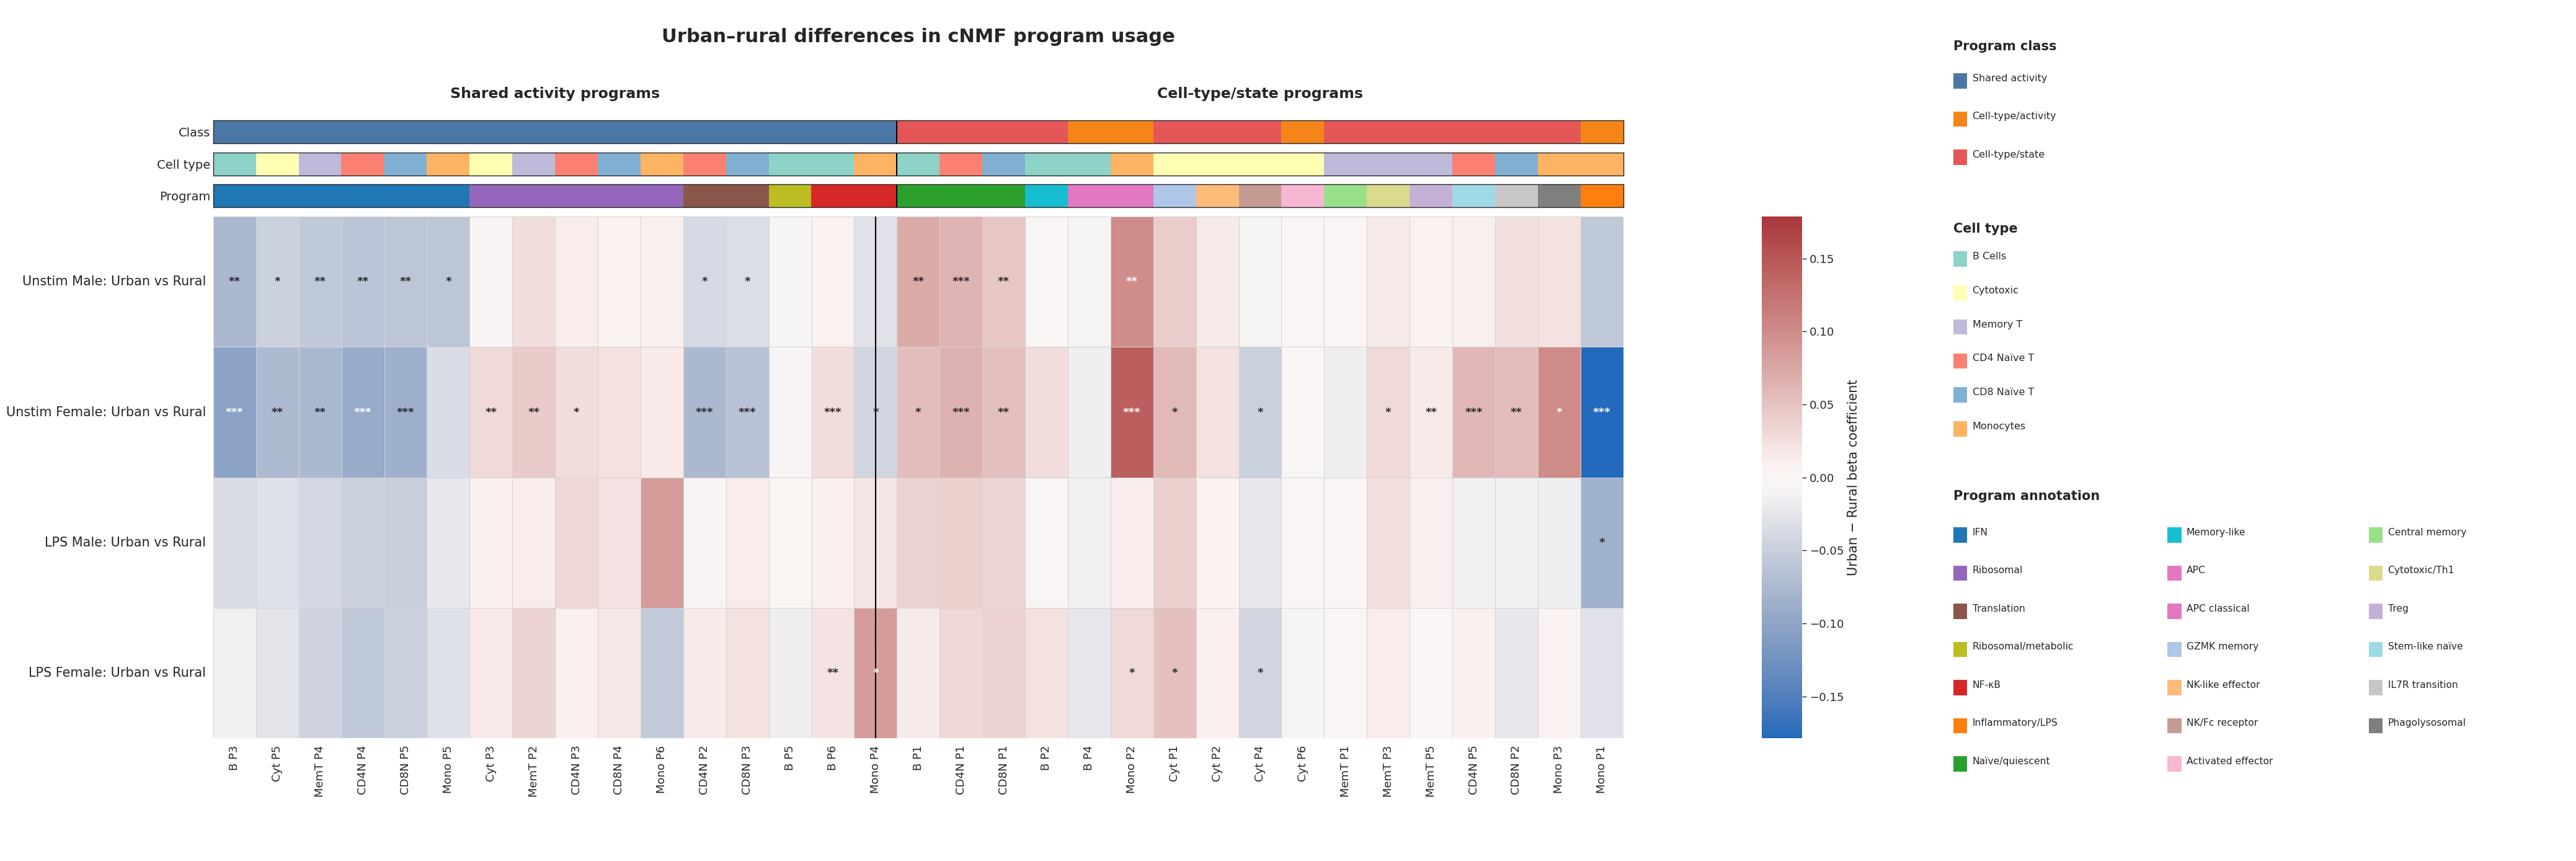

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec

# =========================================================
# 0. SETTINGS
# =========================================================

file_path = "cNMF_Annotation_Celltype.xlsx"
output_prefix = "cNMF_program_usage_heatmap_FINAL_FIXED"

coef_col = "Program Usage Urban - Rural Beta Coefficient"
padj_col = "FDR-padj_BH"
condition_col = "Sub-group"

contrast_order = [
    "Unstim Male: Urban vs Rural",
    "Unstim Female: Urban vs Rural",
    "LPS Male: Urban vs Rural",
    "LPS Female: Urban vs Rural"
]

contrast_map = {
    "Unstim-Male-Urban": "Unstim Male: Urban vs Rural",
    "Unstim-Female-Urban": "Unstim Female: Urban vs Rural",
    "LPS-Male-Urban": "LPS Male: Urban vs Rural",
    "LPS-Female-Urban": "LPS Female: Urban vs Rural",
    "Unsitm-Male-Urban": "Unstim Male: Urban vs Rural",
    "Unsitm-Female-Urban": "Unstim Female: Urban vs Rural"
}

keep_conditions = [
    "Unstim-Male-Urban",
    "Unstim-Female-Urban",
    "LPS-Male-Urban",
    "LPS-Female-Urban"
]

# =========================================================
# 1. READ EXCEL AND FIX HEADER
# =========================================================

raw = pd.read_excel(file_path, header=None)

header_row = None
for i in range(raw.shape[0]):
    row = raw.iloc[i].astype(str).str.strip().tolist()
    if "Celltype" in row and "Gene Program" in row:
        header_row = i
        break

if header_row is None:
    raise ValueError("Could not find the header row containing Celltype and Gene Program.")

headers = raw.iloc[header_row].astype(str).str.strip().tolist()
subheaders = raw.iloc[header_row + 1].astype(str).str.strip().tolist()

clean_headers = []
for h, sh in zip(headers, subheaders):
    if h in ["", "nan", "None"]:
        clean_headers.append(sh)
    elif h in ["Cell Type Programs", "Activity Programs"] and sh not in ["", "nan", "None"]:
        clean_headers.append(sh)
    else:
        clean_headers.append(h)

df = raw.iloc[header_row + 2:].copy()
df.columns = clean_headers

df = df.dropna(axis=0, how="all")
df = df.dropna(axis=1, how="all")
df.columns = df.columns.astype(str).str.strip()
df = df.loc[:, df.columns != "nan"]
df = df.loc[:, ~df.columns.duplicated()].copy()

annotation_cols = [
    "Celltype",
    "Gene Program",
    "ProgramDefining Genes",
    "Final Program Annotation",
    "Program Class"
]

df[annotation_cols] = df[annotation_cols].ffill()

# =========================================================
# 2. PREPARE HEATMAP DATA
# =========================================================

df["Condition"] = (
    df[condition_col]
    .astype(str)
    .str.strip()
    .str.replace("Unsitm", "Unstim", regex=False)
)

df_hm = df[df["Condition"].isin(keep_conditions)].copy()

df_hm[coef_col] = pd.to_numeric(df_hm[coef_col], errors="coerce")
df_hm[padj_col] = pd.to_numeric(df_hm[padj_col], errors="coerce")
df_hm = df_hm.dropna(subset=[coef_col]).copy()

df_hm["Contrast"] = df_hm["Condition"].map(contrast_map)

celltype_short_map = {
    "B Cells": "B",
    "Cytotoxic": "Cyt",
    "Memory T": "MemT",
    "CD4 Naïve T": "CD4N",
    "CD8 Naïve T": "CD8N",
    "Monocytes": "Mono"
}

df_hm["Celltype_short"] = df_hm["Celltype"].replace(celltype_short_map)

df_hm["Program_Label"] = (
    df_hm["Celltype_short"].astype(str).str.strip()
    + " "
    + df_hm["Gene Program"].astype(str).str.strip()
)

# =========================================================
# 3. BIOLOGICAL PROGRAM ANNOTATION
# =========================================================

subgroup_map = {
    "B P1": "Naïve/quiescent",
    "B P2": "Memory-like",
    "B P3": "IFN",
    "B P4": "APC",
    "B P5": "Ribosomal/metabolic",
    "B P6": "NF-κB",

    "Cyt P1": "GZMK memory",
    "Cyt P2": "NK-like effector",
    "Cyt P3": "Ribosomal",
    "Cyt P4": "NK/Fc receptor",
    "Cyt P5": "IFN",
    "Cyt P6": "Activated effector",

    "MemT P1": "Central memory",
    "MemT P2": "Ribosomal",
    "MemT P3": "Cytotoxic/Th1",
    "MemT P4": "IFN",
    "MemT P5": "Treg",

    "CD4N P1": "Naïve/quiescent",
    "CD4N P2": "Translation",
    "CD4N P3": "Ribosomal",
    "CD4N P4": "IFN",
    "CD4N P5": "Stem-like naïve",

    "CD8N P1": "Naïve/quiescent",
    "CD8N P2": "IL7R transition",
    "CD8N P3": "Translation",
    "CD8N P4": "Ribosomal",
    "CD8N P5": "IFN",

    "Mono P1": "Inflammatory/LPS",
    "Mono P2": "APC classical",
    "Mono P3": "Phagolysosomal",
    "Mono P4": "NF-κB",
    "Mono P5": "IFN",
    "Mono P6": "Ribosomal"
}

df_hm["Biological_Subgroup"] = df_hm["Program_Label"].map(subgroup_map)

df_hm.loc[df_hm["Program_Label"] == "Mono P6", "Program Class"] = "Shared activity"

# =========================================================
# 4. ORDER PROGRAMS
# =========================================================

class_order = {
    "Shared activity": 0,
    "Shared/cell-type activity": 0,
    "Cell-type/activity": 1,
    "Cell-type/state": 1
}

celltype_order = {
    "B Cells": 0,
    "Cytotoxic": 1,
    "Memory T": 2,
    "CD4 Naïve T": 3,
    "CD8 Naïve T": 4,
    "Monocytes": 5
}

shared_subgroup_order = {
    "IFN": 0,
    "Ribosomal": 1,
    "Translation": 2,
    "Ribosomal/metabolic": 3,
    "NF-κB": 4,
    "Inflammatory/LPS": 5
}

cell_specific_subgroup_order = {
    "Naïve/quiescent": 0,
    "Memory-like": 1,
    "APC": 2,
    "APC classical": 3,
    "GZMK memory": 4,
    "NK-like effector": 5,
    "NK/Fc receptor": 6,
    "Activated effector": 7,
    "Central memory": 8,
    "Cytotoxic/Th1": 9,
    "Treg": 10,
    "Stem-like naïve": 11,
    "IL7R transition": 12,
    "Phagolysosomal": 13
}

df_hm["Program_Class_Order"] = df_hm["Program Class"].map(class_order).fillna(1)
df_hm["Celltype_Order"] = df_hm["Celltype"].map(celltype_order).fillna(99)

df_hm["Program_Number"] = (
    df_hm["Gene Program"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

def get_subgroup_order(row):
    if row["Program_Class_Order"] == 0:
        return shared_subgroup_order.get(row["Biological_Subgroup"], 50)
    else:
        return cell_specific_subgroup_order.get(row["Biological_Subgroup"], 50)

df_hm["Subgroup_Order"] = df_hm.apply(get_subgroup_order, axis=1)

program_order = (
    df_hm[
        [
            "Program_Label",
            "Program_Class_Order",
            "Subgroup_Order",
            "Celltype_Order",
            "Program_Number"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "Program_Class_Order",
            "Subgroup_Order",
            "Celltype_Order",
            "Program_Number"
        ]
    )
    ["Program_Label"]
    .tolist()
)

# =========================================================
# 5. MATRICES
# =========================================================

heatmap_df = df_hm.pivot_table(
    index="Contrast",
    columns="Program_Label",
    values=coef_col,
    aggfunc="first"
).reindex(index=contrast_order, columns=program_order)

def p_to_star(p):
    if pd.isna(p):
        return ""
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

df_hm["stars"] = df_hm[padj_col].apply(p_to_star)

stars_df = df_hm.pivot_table(
    index="Contrast",
    columns="Program_Label",
    values="stars",
    aggfunc="first"
).reindex(index=contrast_order, columns=program_order)

col_meta = (
    df_hm[
        [
            "Program_Label",
            "Program Class",
            "Celltype",
            "Biological_Subgroup",
            "Program_Class_Order"
        ]
    ]
    .drop_duplicates()
    .set_index("Program_Label")
    .reindex(program_order)
)

# =========================================================
# 6. COLORS
# =========================================================

program_class_palette = {
    "Shared activity": "#4C78A8",
    "Shared/cell-type activity": "#72B7B2",
    "Cell-type/activity": "#F58518",
    "Cell-type/state": "#E45756"
}

celltype_palette = {
    "B Cells": "#8DD3C7",
    "Cytotoxic": "#FFFFB3",
    "Memory T": "#BEBADA",
    "CD4 Naïve T": "#FB8072",
    "CD8 Naïve T": "#80B1D3",
    "Monocytes": "#FDB462"
}

subgroup_palette = {
    "IFN": "#1F77B4",
    "Ribosomal": "#9467BD",
    "Translation": "#8C564B",
    "Ribosomal/metabolic": "#BCBD22",
    "NF-κB": "#D62728",
    "Inflammatory/LPS": "#FF7F0E",
    "Naïve/quiescent": "#2CA02C",
    "Memory-like": "#17BECF",
    "APC": "#E377C2",
    "APC classical": "#E377C2",
    "GZMK memory": "#AEC7E8",
    "NK-like effector": "#FFBB78",
    "NK/Fc receptor": "#C49C94",
    "Activated effector": "#F7B6D2",
    "Central memory": "#98DF8A",
    "Cytotoxic/Th1": "#DBDB8D",
    "Treg": "#C5B0D5",
    "Stem-like naïve": "#9EDAE5",
    "IL7R transition": "#C7C7C7",
    "Phagolysosomal": "#7F7F7F"
}

def make_color_bar(series, palette):
    colors = series.map(palette).fillna("#FFFFFF").tolist()
    unique_colors = list(dict.fromkeys(colors))
    color_to_int = {c: i for i, c in enumerate(unique_colors)}
    bar = np.array([[color_to_int[c] for c in colors]])
    cmap = ListedColormap(unique_colors)
    return bar, cmap

class_bar, class_cmap = make_color_bar(col_meta["Program Class"], program_class_palette)
celltype_bar, celltype_cmap = make_color_bar(col_meta["Celltype"], celltype_palette)
program_bar, program_cmap = make_color_bar(col_meta["Biological_Subgroup"], subgroup_palette)

# =========================================================
# 7. FINAL PLOT
# =========================================================

sns.set(style="white", context="paper")

vmax = np.nanmax(np.abs(heatmap_df.values))

fig = plt.figure(figsize=(42, 18), constrained_layout=False)

gs = gridspec.GridSpec(
    nrows=7,
    ncols=3,
    figure=fig,
    width_ratios=[28, 0.8, 12.5],
    height_ratios=[0.8, 0.45, 0.30, 0.30, 0.30, 6.8, 1.4],
    wspace=0.20,
    hspace=0.08
)

ax_title = fig.add_subplot(gs[0, 0])
ax_block = fig.add_subplot(gs[1, 0])
ax_class = fig.add_subplot(gs[2, 0])
ax_celltype = fig.add_subplot(gs[3, 0])
ax_program = fig.add_subplot(gs[4, 0])
ax_heat = fig.add_subplot(gs[5, 0])
ax_cbar = fig.add_subplot(gs[5, 1])
ax_legend = fig.add_subplot(gs[0:7, 2])

ax_title.axis("off")
ax_title.text(
    0.5, 0.5,
    "Urban–rural differences in cNMF program usage",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold"
)

ax_block.set_xlim(0, heatmap_df.shape[1])
ax_block.set_ylim(0, 1)
ax_block.axis("off")

ordered_meta = col_meta.copy()
ordered_meta["x"] = np.arange(len(ordered_meta))

shared_mask = ordered_meta["Program_Class_Order"] == 0
specific_mask = ordered_meta["Program_Class_Order"] == 1

if shared_mask.any():
    x0 = ordered_meta.loc[shared_mask, "x"].min()
    x1 = ordered_meta.loc[shared_mask, "x"].max() + 1
    ax_block.text(
        (x0 + x1) / 2,
        0.5,
        "Shared activity programs",
        ha="center",
        va="center",
        fontsize=17,
        fontweight="bold"
    )

if specific_mask.any():
    x0 = ordered_meta.loc[specific_mask, "x"].min()
    x1 = ordered_meta.loc[specific_mask, "x"].max() + 1
    ax_block.text(
        (x0 + x1) / 2,
        0.5,
        "Cell-type/state programs",
        ha="center",
        va="center",
        fontsize=17,
        fontweight="bold"
    )

def plot_bar(ax, bar, cmap, label):
    ax.imshow(bar, aspect="auto", cmap=cmap)
    ax.set_xticks([])
    ax.set_yticks([0])
    ax.set_yticklabels([label], fontsize=14)
    ax.tick_params(length=0)

plot_bar(ax_class, class_bar, class_cmap, "Class")
plot_bar(ax_celltype, celltype_bar, celltype_cmap, "Cell type")
plot_bar(ax_program, program_bar, program_cmap, "Program")

sns.heatmap(
    heatmap_df,
    cmap="vlag",
    center=0,
    vmin=-vmax,
    vmax=vmax,
    annot=stars_df,
    fmt="",
    annot_kws={"fontsize": 13, "fontweight": "bold"},
    linewidths=0.55,
    linecolor="lightgrey",
    cbar_ax=ax_cbar,
    cbar_kws={"label": "Urban − Rural beta coefficient"},
    ax=ax_heat
)

ax_heat.set_xlabel("")
ax_heat.set_ylabel("")
ax_heat.set_xticklabels(ax_heat.get_xticklabels(), rotation=90, ha="center", fontsize=13)
ax_heat.set_yticklabels(ax_heat.get_yticklabels(), rotation=0, fontsize=15)

ax_cbar.tick_params(labelsize=13)
ax_cbar.set_ylabel("Urban − Rural beta coefficient", fontsize=15)

if shared_mask.any() and specific_mask.any():
    sep = ordered_meta.loc[shared_mask, "x"].max() + 0.5
    for ax in [ax_class, ax_celltype, ax_program, ax_heat]:
        ax.axvline(sep, color="black", linewidth=1.5)

# =========================================================
# 8. LEGEND
# =========================================================

ax_legend.axis("off")
ax_legend.set_xlim(0, 1)
ax_legend.set_ylim(0, 1)

def draw_legend(ax, palette, values, title, x, y, dy=0.045, fontsize=11.5, title_size=15):
    ax.text(
        x, y, title,
        fontsize=title_size,
        fontweight="bold",
        ha="left",
        va="top",
        transform=ax.transAxes
    )

    y -= dy

    for label, color in palette.items():
        if label in values:
            ax.add_patch(
                mpatches.Rectangle(
                    (x, y - 0.012),
                    0.022,
                    0.018,
                    facecolor=color,
                    edgecolor="none",
                    transform=ax.transAxes
                )
            )

            ax.text(
                x + 0.030,
                y,
                label,
                fontsize=fontsize,
                ha="left",
                va="center",
                transform=ax.transAxes
            )

            y -= dy

    return y

y = 0.96

y = draw_legend(
    ax_legend,
    program_class_palette,
    col_meta["Program Class"].dropna().unique(),
    "Program class",
    x=0.02,
    y=y,
    dy=0.045,
    fontsize=11.5,
    title_size=15
)

y -= 0.035

y = draw_legend(
    ax_legend,
    celltype_palette,
    col_meta["Celltype"].dropna().unique(),
    "Cell type",
    x=0.02,
    y=y,
    dy=0.040,
    fontsize=11.5,
    title_size=15
)

y -= 0.035

ax_legend.text(
    0.02,
    y,
    "Program annotation",
    fontsize=15,
    fontweight="bold",
    ha="left",
    va="top",
    transform=ax_legend.transAxes
)

subgroup_values = list(col_meta["Biological_Subgroup"].dropna().unique())

subgroup_items = [
    (label, color)
    for label, color in subgroup_palette.items()
    if label in subgroup_values
]

start_y = y - 0.050
dy = 0.045

n_cols = 3
items_per_col = int(np.ceil(len(subgroup_items) / n_cols))
x_positions = [0.02, 0.36, 0.68]

for i, (label, color) in enumerate(subgroup_items):
    col = i // items_per_col
    row = i % items_per_col

    x = x_positions[col]
    yy = start_y - row * dy

    ax_legend.add_patch(
        mpatches.Rectangle(
            (x, yy - 0.012),
            0.022,
            0.018,
            facecolor=color,
            edgecolor="none",
            transform=ax_legend.transAxes
        )
    )

    ax_legend.text(
        x + 0.030,
        yy,
        label,
        fontsize=11.2,
        ha="left",
        va="center",
        transform=ax_legend.transAxes
    )

# =========================================================
# 9. SAVE OUTPUTS
# =========================================================

plt.subplots_adjust(
    left=0.08,
    right=0.985,
    top=0.94,
    bottom=0.18
)

plt.savefig(f"{output_prefix}.pdf", bbox_inches="tight")
plt.savefig(f"{output_prefix}.png", dpi=600, bbox_inches="tight")

plt.show()

# =========================================================
# 10. EXPORT TABLES
# =========================================================

heatmap_df.to_csv(f"{output_prefix}_matrix.csv")
stars_df.to_csv(f"{output_prefix}_stars.csv")
df_hm.to_csv(f"{output_prefix}_long_input.csv", index=False)
col_meta.to_csv(f"{output_prefix}_column_metadata.csv")

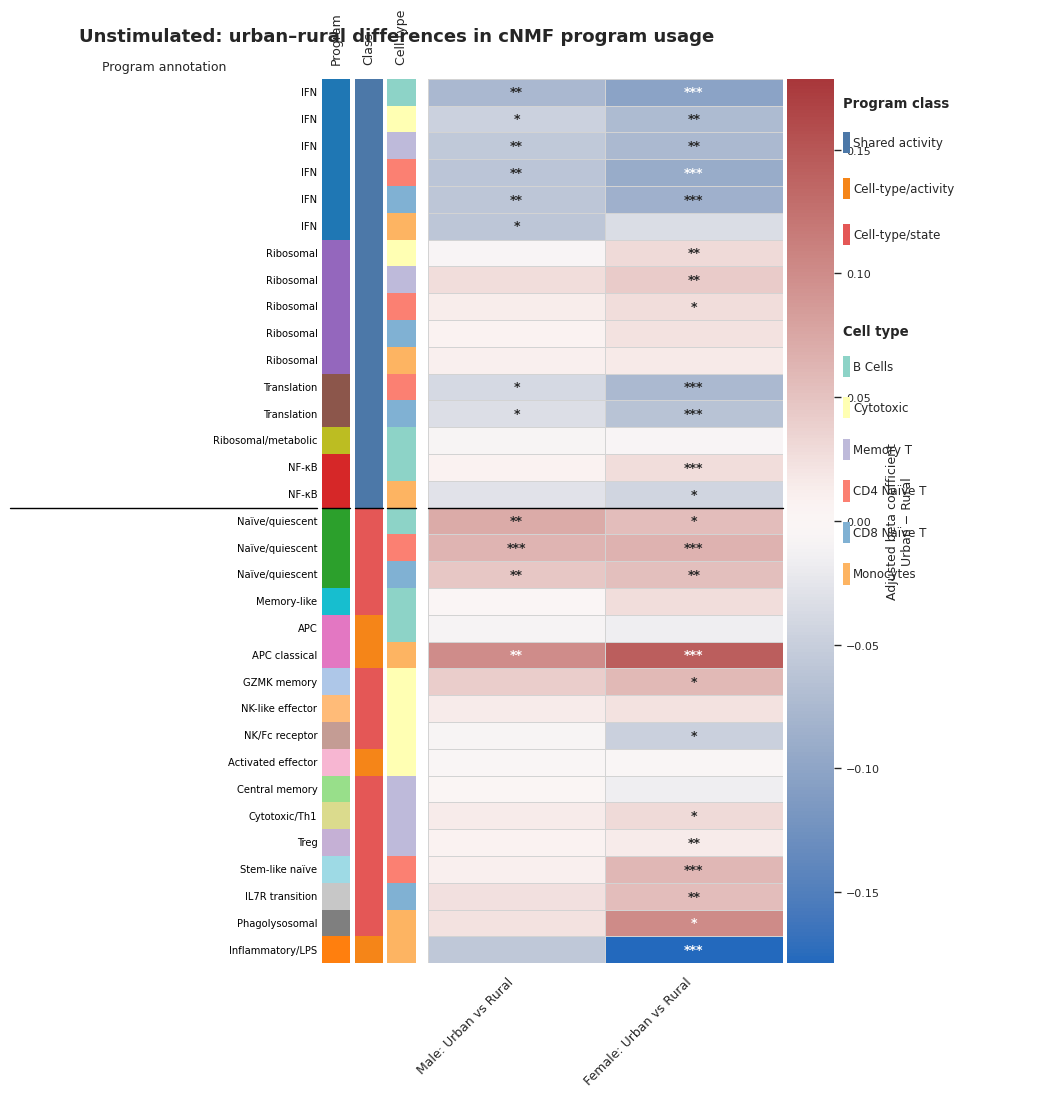

Saved: cNMF_beta_split_vertical_Unstim_MAIN_beta.pdf
Saved: cNMF_beta_split_vertical_Unstim_MAIN_beta.png


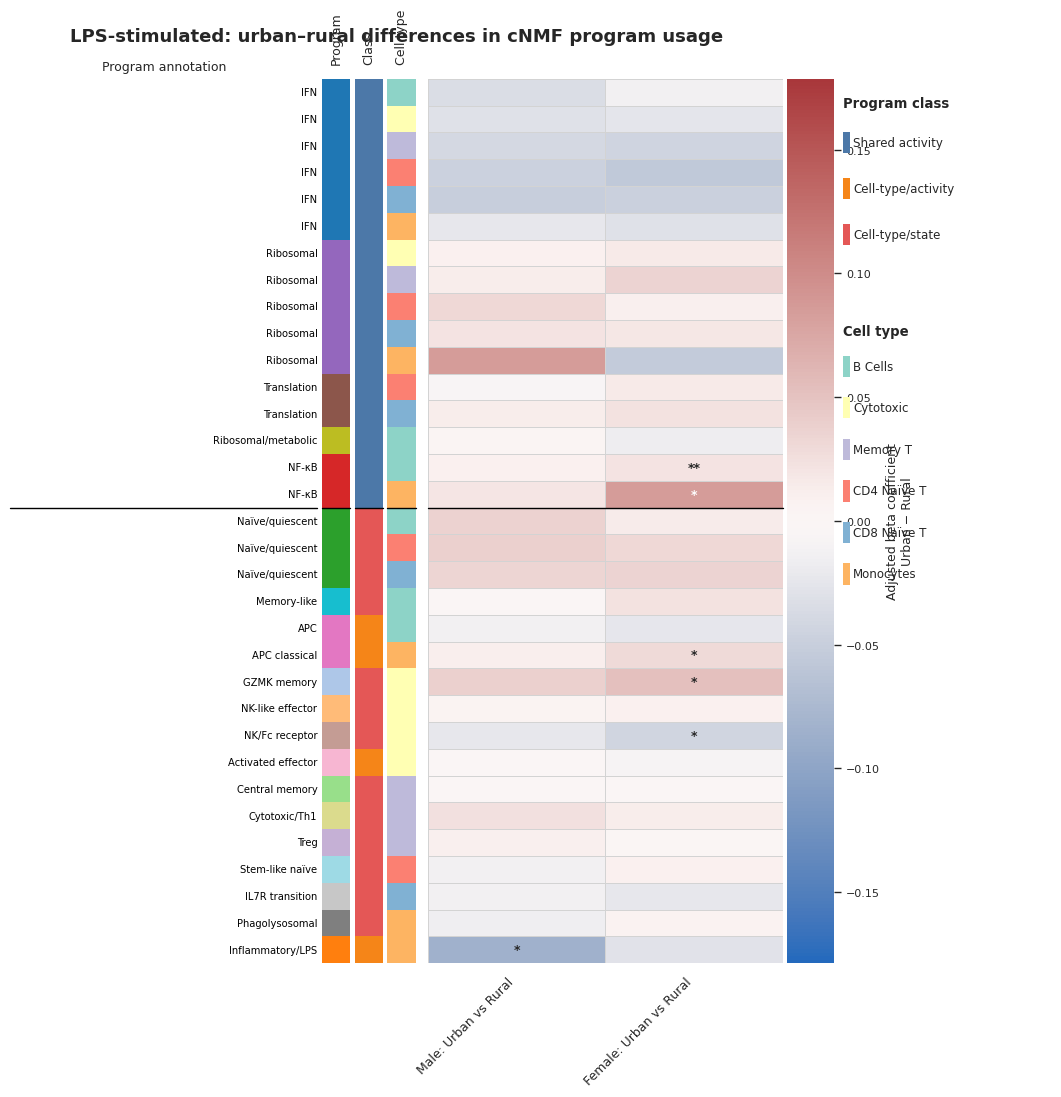

Saved: cNMF_beta_split_vertical_LPS_SUPPLEMENTARY_beta.pdf
Saved: cNMF_beta_split_vertical_LPS_SUPPLEMENTARY_beta.png
Done.


In [1]:
# =========================================================
# cNMF beta heatmaps: split Unstim and LPS, vertical layout
# Illustrator-safe categorical annotation bars
# =========================================================

import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

import seaborn as sns


# =========================================================
# 0. ILLUSTRATOR / PDF SETTINGS
# =========================================================

# Keep text editable in Illustrator
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"

# Avoid path simplification issues
mpl.rcParams["path.simplify"] = False


# =========================================================
# 1. SETTINGS
# =========================================================

file_path = "cNMF_Annotation_Celltype.xlsx"
output_prefix = "cNMF_beta_split_vertical"

coef_col = "Program Usage Urban - Rural Beta Coefficient"
padj_col = "FDR-padj_BH"
condition_col = "Sub-group"

# Keep the same color scale for Unstim and LPS
USE_COMMON_COLOR_SCALE = True

# Panels to generate
panels = [
    {"stim": "Unstim", "label": "Unstimulated", "tag": "MAIN"},
    {"stim": "LPS", "label": "LPS-stimulated", "tag": "SUPPLEMENTARY"},
]

# Columns in each heatmap
sex_contrast_order = [
    "Male: Urban vs Rural",
    "Female: Urban vs Rural",
]

# Rows from the statistics table to keep
keep_conditions = [
    "Unstim-Male-Urban",
    "Unstim-Female-Urban",
    "LPS-Male-Urban",
    "LPS-Female-Urban",
]


# =========================================================
# 2. READ EXCEL AND FIX HEADER
# =========================================================

raw = pd.read_excel(file_path, header=None)

header_row = None
for i in range(raw.shape[0]):
    row = raw.iloc[i].astype(str).str.strip().tolist()
    if "Celltype" in row and "Gene Program" in row:
        header_row = i
        break

if header_row is None:
    raise ValueError(
        "Could not find the header row containing both 'Celltype' and 'Gene Program'."
    )

headers = raw.iloc[header_row].astype(str).str.strip().tolist()
subheaders = raw.iloc[header_row + 1].astype(str).str.strip().tolist()

clean_headers = []
for h, sh in zip(headers, subheaders):
    h = str(h).strip()
    sh = str(sh).strip()

    if h in ["", "nan", "None"]:
        clean_headers.append(sh)
    elif h in ["Cell Type Programs", "Activity Programs"] and sh not in ["", "nan", "None"]:
        clean_headers.append(sh)
    else:
        clean_headers.append(h)

df = raw.iloc[header_row + 2:].copy()
df.columns = clean_headers

df = df.dropna(axis=0, how="all")
df = df.dropna(axis=1, how="all")
df.columns = df.columns.astype(str).str.strip()
df = df.loc[:, df.columns != "nan"]
df = df.loc[:, ~df.columns.duplicated()].copy()

annotation_cols = [
    "Celltype",
    "Gene Program",
    "ProgramDefining Genes",
    "Final Program Annotation",
    "Program Class",
]

missing_ann = [c for c in annotation_cols if c not in df.columns]
if missing_ann:
    raise ValueError(f"Missing expected annotation columns: {missing_ann}")

missing_stats = [c for c in [condition_col, coef_col, padj_col] if c not in df.columns]
if missing_stats:
    raise ValueError(f"Missing expected statistics columns: {missing_stats}")

df[annotation_cols] = df[annotation_cols].ffill()


# =========================================================
# 3. PREPARE HEATMAP DATA
# =========================================================

df["Condition"] = (
    df[condition_col]
    .astype(str)
    .str.strip()
    .str.replace("Unsitm", "Unstim", regex=False)
)

df_hm = df[df["Condition"].isin(keep_conditions)].copy()

def parse_stim(cond):
    cond = str(cond)
    if cond.startswith("Unstim"):
        return "Unstim"
    if cond.startswith("LPS"):
        return "LPS"
    return np.nan

def parse_sex(cond):
    cond = str(cond)
    if "Female" in cond:
        return "Female"
    if "Male" in cond:
        return "Male"
    return np.nan

df_hm["Stimulation_split"] = df_hm["Condition"].apply(parse_stim)
df_hm["Sex_split"] = df_hm["Condition"].apply(parse_sex)
df_hm["Contrast"] = df_hm["Sex_split"] + ": Urban vs Rural"

df_hm[coef_col] = pd.to_numeric(df_hm[coef_col], errors="coerce")
df_hm[padj_col] = pd.to_numeric(df_hm[padj_col], errors="coerce")

df_hm["Heatmap_value"] = df_hm[coef_col]
value_label = "Adjusted beta coefficient\nUrban − Rural"

df_hm = df_hm.dropna(subset=["Heatmap_value"]).copy()


# =========================================================
# 4. PROGRAM LABELS
# =========================================================

celltype_short_map = {
    "B Cells": "B",
    "B cells": "B",

    "Cytotoxic": "Cyt",
    "Cytotoxic T/NK cells": "Cyt",
    "Cytotoxic T-NK cells": "Cyt",
    "Cytotoxic T/NK": "Cyt",

    "Memory T": "MemT",
    "Memory T cells": "MemT",

    "CD4 Naïve T": "CD4N",
    "CD4 Naive T": "CD4N",
    "Naive CD4 T cells": "CD4N",

    "CD8 Naïve T": "CD8N",
    "CD8 Naive T": "CD8N",
    "Naive CD8 T cells": "CD8N",

    "Monocytes": "Mono",
}

df_hm["Celltype_short"] = df_hm["Celltype"].replace(celltype_short_map)

df_hm["Program_Label"] = (
    df_hm["Celltype_short"].astype(str).str.strip()
    + " "
    + df_hm["Gene Program"].astype(str).str.strip()
)


# =========================================================
# 5. BIOLOGICAL PROGRAM ANNOTATIONS
# =========================================================

subgroup_map = {
    # B cells
    "B P1": "Naïve/quiescent",
    "B P2": "Memory-like",
    "B P3": "IFN",
    "B P4": "APC",
    "B P5": "Ribosomal/metabolic",
    "B P6": "NF-κB",

    # Cytotoxic T/NK
    "Cyt P1": "GZMK memory",
    "Cyt P2": "NK-like effector",
    "Cyt P3": "Ribosomal",
    "Cyt P4": "NK/Fc receptor",
    "Cyt P5": "IFN",
    "Cyt P6": "Activated effector",

    # Memory T
    "MemT P1": "Central memory",
    "MemT P2": "Ribosomal",
    "MemT P3": "Cytotoxic/Th1",
    "MemT P4": "IFN",
    "MemT P5": "Treg",

    # CD4 naive T
    "CD4N P1": "Naïve/quiescent",
    "CD4N P2": "Translation",
    "CD4N P3": "Ribosomal",
    "CD4N P4": "IFN",
    "CD4N P5": "Stem-like naïve",

    # CD8 naive T
    "CD8N P1": "Naïve/quiescent",
    "CD8N P2": "IL7R transition",
    "CD8N P3": "Translation",
    "CD8N P4": "Ribosomal",
    "CD8N P5": "IFN",

    # Monocytes
    "Mono P1": "Inflammatory/LPS",
    "Mono P2": "APC classical",
    "Mono P3": "Phagolysosomal",
    "Mono P4": "NF-κB",
    "Mono P5": "IFN",
    "Mono P6": "Ribosomal",
}

df_hm["Biological_Subgroup"] = df_hm["Program_Label"].map(subgroup_map)

# Optional: keep Mono P6 with shared programs, as in your previous plot logic
df_hm.loc[df_hm["Program_Label"] == "Mono P6", "Program Class"] = "Shared activity"


# =========================================================
# 6. ORDER PROGRAMS
# =========================================================

class_order = {
    "Shared activity": 0,
    "Shared/cell-type activity": 0,
    "Cell-type/activity": 1,
    "Cell-type/state": 1,
}

celltype_order = {
    "B Cells": 0,
    "B cells": 0,

    "Cytotoxic": 1,
    "Cytotoxic T/NK cells": 1,
    "Cytotoxic T-NK cells": 1,
    "Cytotoxic T/NK": 1,

    "Memory T": 2,
    "Memory T cells": 2,

    "CD4 Naïve T": 3,
    "CD4 Naive T": 3,
    "Naive CD4 T cells": 3,

    "CD8 Naïve T": 4,
    "CD8 Naive T": 4,
    "Naive CD8 T cells": 4,

    "Monocytes": 5,
}

shared_subgroup_order = {
    "IFN": 0,
    "Ribosomal": 1,
    "Translation": 2,
    "Ribosomal/metabolic": 3,
    "NF-κB": 4,
    "Inflammatory/LPS": 5,
}

cell_specific_subgroup_order = {
    "Naïve/quiescent": 0,
    "Memory-like": 1,
    "APC": 2,
    "APC classical": 3,
    "GZMK memory": 4,
    "NK-like effector": 5,
    "NK/Fc receptor": 6,
    "Activated effector": 7,
    "Central memory": 8,
    "Cytotoxic/Th1": 9,
    "Treg": 10,
    "Stem-like naïve": 11,
    "IL7R transition": 12,
    "Phagolysosomal": 13,
}

df_hm["Program_Class_Order"] = df_hm["Program Class"].map(class_order).fillna(1)
df_hm["Celltype_Order"] = df_hm["Celltype"].map(celltype_order).fillna(99)

df_hm["Program_Number"] = (
    df_hm["Gene Program"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

def get_subgroup_order(row):
    if row["Program_Class_Order"] == 0:
        return shared_subgroup_order.get(row["Biological_Subgroup"], 50)
    return cell_specific_subgroup_order.get(row["Biological_Subgroup"], 50)

df_hm["Subgroup_Order"] = df_hm.apply(get_subgroup_order, axis=1)

program_order = (
    df_hm[
        [
            "Program_Label",
            "Program_Class_Order",
            "Subgroup_Order",
            "Celltype_Order",
            "Program_Number",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "Program_Class_Order",
            "Subgroup_Order",
            "Celltype_Order",
            "Program_Number",
        ]
    )
    ["Program_Label"]
    .tolist()
)

row_meta = (
    df_hm[
        [
            "Program_Label",
            "Program Class",
            "Celltype",
            "Biological_Subgroup",
            "Program_Class_Order",
            "Subgroup_Order",
            "Celltype_Order",
            "Program_Number",
        ]
    ]
    .drop_duplicates()
    .set_index("Program_Label")
    .reindex(program_order)
)


# =========================================================
# 7. SIGNIFICANCE STARS
# =========================================================

def p_to_star(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

df_hm["stars"] = df_hm[padj_col].apply(p_to_star)


# =========================================================
# 8. COLOR PALETTES
# =========================================================

program_class_palette = {
    "Shared activity": "#4C78A8",
    "Shared/cell-type activity": "#72B7B2",
    "Cell-type/activity": "#F58518",
    "Cell-type/state": "#E45756",
}

celltype_palette = {
    "B Cells": "#8DD3C7",
    "B cells": "#8DD3C7",

    "Cytotoxic": "#FFFFB3",
    "Cytotoxic T/NK cells": "#FFFFB3",
    "Cytotoxic T-NK cells": "#FFFFB3",
    "Cytotoxic T/NK": "#FFFFB3",

    "Memory T": "#BEBADA",
    "Memory T cells": "#BEBADA",

    "CD4 Naïve T": "#FB8072",
    "CD4 Naive T": "#FB8072",
    "Naive CD4 T cells": "#FB8072",

    "CD8 Naïve T": "#80B1D3",
    "CD8 Naive T": "#80B1D3",
    "Naive CD8 T cells": "#80B1D3",

    "Monocytes": "#FDB462",
}

subgroup_palette = {
    "IFN": "#1F77B4",
    "Ribosomal": "#9467BD",
    "Translation": "#8C564B",
    "Ribosomal/metabolic": "#BCBD22",
    "NF-κB": "#D62728",
    "Inflammatory/LPS": "#FF7F0E",

    "Naïve/quiescent": "#2CA02C",
    "Memory-like": "#17BECF",
    "APC": "#E377C2",
    "APC classical": "#E377C2",
    "GZMK memory": "#AEC7E8",
    "NK-like effector": "#FFBB78",
    "NK/Fc receptor": "#C49C94",
    "Activated effector": "#F7B6D2",
    "Central memory": "#98DF8A",
    "Cytotoxic/Th1": "#DBDB8D",
    "Treg": "#C5B0D5",
    "Stem-like naïve": "#9EDAE5",
    "IL7R transition": "#C7C7C7",
    "Phagolysosomal": "#7F7F7F",
}


# =========================================================
# 9. COMMON COLOR SCALE
# =========================================================

if USE_COMMON_COLOR_SCALE:
    global_vmax = np.nanmax(np.abs(df_hm["Heatmap_value"].values))
else:
    global_vmax = None


# =========================================================
# 10. PLOTTING HELPERS
# =========================================================

sns.set(style="white", context="paper")


def plot_program_text_left(ax, labels, n_rows):
    """
    Biological program annotation text on the far left.
    No colored background.
    """
    ax.set_xlim(0, 1)
    ax.set_ylim(n_rows, 0)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("white")

    for i, label in enumerate(labels):
        if pd.isna(label):
            continue

        ax.text(
            1.0,
            i + 0.5,
            str(label),
            ha="right",
            va="center",
            fontsize=7.2,
            color="black",
            clip_on=False,
        )

    ax.set_title("Program annotation", fontsize=9, pad=6)

    for spine in ax.spines.values():
        spine.set_visible(False)


def plot_vector_side_bar(ax, values, palette, label, n_rows):
    """
    Draw categorical annotation bars as individual vector rectangles.
    This avoids Illustrator collapsing/reinterpreting imshow colors.
    """
    ax.set_xlim(0, 1)
    ax.set_ylim(n_rows, 0)
    ax.set_xticks([])
    ax.set_yticks([])

    for i, value in enumerate(values):
        color = palette.get(value, "#FFFFFF")

        rect = mpatches.Rectangle(
            (0, i),
            1,
            1,
            facecolor=color,
            edgecolor="none",
            linewidth=0,
            rasterized=False,
        )
        ax.add_patch(rect)

    ax.set_title(label, fontsize=9, rotation=90, x=0.5, y=1.01)

    for spine in ax.spines.values():
        spine.set_visible(False)


def draw_simple_legend(
    ax,
    palette,
    values,
    title,
    x,
    y,
    dy=0.045,
    fontsize=8.5,
    title_size=9.5,
):
    values = set([v for v in values if not pd.isna(v)])

    ax.text(
        x,
        y,
        title,
        fontsize=title_size,
        fontweight="bold",
        ha="left",
        va="top",
        transform=ax.transAxes,
    )

    y -= dy

    for label, color in palette.items():
        if label in values:
            ax.add_patch(
                mpatches.Rectangle(
                    (x, y - 0.012),
                    0.035,
                    0.024,
                    facecolor=color,
                    edgecolor="none",
                    transform=ax.transAxes,
                    rasterized=False,
                )
            )

            ax.text(
                x + 0.047,
                y,
                label,
                fontsize=fontsize,
                ha="left",
                va="center",
                transform=ax.transAxes,
            )

            y -= dy

    return y


def add_row_separator(ax_list, row_meta):
    """
    Draw a horizontal separator between shared and cell-type/state programs.
    """
    ordered_meta = row_meta.copy()
    ordered_meta["y"] = np.arange(len(ordered_meta))

    shared_mask = ordered_meta["Program_Class_Order"] == 0
    specific_mask = ordered_meta["Program_Class_Order"] == 1

    if shared_mask.any() and specific_mask.any():
        sep = ordered_meta.loc[shared_mask, "y"].max() + 1

        for ax in ax_list:
            ax.axhline(
                sep,
                color="black",
                linewidth=1.0,
                rasterized=False,
                clip_on=False,
            )


# =========================================================
# 11. MAKE ONE PANEL
# =========================================================

def make_panel(stim, panel_label, panel_tag):
    sub = df_hm[df_hm["Stimulation_split"] == stim].copy()

    if sub.empty:
        print(f"No rows found for {stim}; skipping.")
        return

    heatmap_df = (
        sub.pivot_table(
            index="Program_Label",
            columns="Contrast",
            values="Heatmap_value",
            aggfunc="first",
        )
        .reindex(index=program_order, columns=sex_contrast_order)
    )

    stars_df = (
        sub.pivot_table(
            index="Program_Label",
            columns="Contrast",
            values="stars",
            aggfunc="first",
        )
        .reindex(index=program_order, columns=sex_contrast_order)
        .fillna("")
    )

    n_rows = heatmap_df.shape[0]

    if USE_COMMON_COLOR_SCALE:
        vmax = global_vmax
    else:
        vmax = np.nanmax(np.abs(heatmap_df.values))

    # Size can be tuned
    fig_height = max(9.0, 0.33 * n_rows)
    fig_width = 11.2

    fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=False)

    # Left to right:
    # 1) program annotation text
    # 2) program annotation color bar
    # 3) class bar
    # 4) cell type bar, directly beside heatmap
    # 5) heatmap
    # 6) colorbar
    # 7) legend
    gs = gridspec.GridSpec(
        nrows=2,
        ncols=8,
        figure=fig,
        height_ratios=[0.45, 10.0],
        width_ratios=[
            1.95,   # far-left program annotation text
            0.18,   # program annotation color bar
            0.18,   # program class bar
            0.18,   # cell type bar, closest to heatmap
            0.02,   # tiny gap before heatmap
            2.25,   # heatmap
            0.30,   # colorbar
            1.35,   # legend
        ],
        wspace=0.035,
        hspace=0.05,
    )

    ax_title = fig.add_subplot(gs[0, :6])

    ax_program_text = fig.add_subplot(gs[1, 0])
    ax_program_bar = fig.add_subplot(gs[1, 1])
    ax_class = fig.add_subplot(gs[1, 2])
    ax_celltype = fig.add_subplot(gs[1, 3])
    ax_gap = fig.add_subplot(gs[1, 4])
    ax_heat = fig.add_subplot(gs[1, 5])
    ax_cbar = fig.add_subplot(gs[1, 6])
    ax_legend = fig.add_subplot(gs[1, 7])

    ax_title.axis("off")
    ax_title.text(
        0.5,
        0.5,
        f"{panel_label}: urban–rural differences in cNMF program usage",
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
    )

    ax_gap.axis("off")

    # Far-left biological annotation text
    plot_program_text_left(
        ax_program_text,
        row_meta["Biological_Subgroup"].tolist(),
        n_rows,
    )

    # Program annotation bar
    plot_vector_side_bar(
        ax_program_bar,
        row_meta["Biological_Subgroup"].tolist(),
        subgroup_palette,
        "Program",
        n_rows,
    )

    # Program class bar
    plot_vector_side_bar(
        ax_class,
        row_meta["Program Class"].tolist(),
        program_class_palette,
        "Class",
        n_rows,
    )

    # Cell type bar directly closest to heatmap
    plot_vector_side_bar(
        ax_celltype,
        row_meta["Celltype"].tolist(),
        celltype_palette,
        "Cell type",
        n_rows,
    )

    # Main heatmap
    sns.heatmap(
        heatmap_df,
        cmap="vlag",
        center=0,
        vmin=-vmax,
        vmax=vmax,
        annot=stars_df,
        fmt="",
        annot_kws={"fontsize": 9, "fontweight": "bold"},
        linewidths=0.45,
        linecolor="lightgrey",
        cbar_ax=ax_cbar,
        cbar_kws={"label": value_label},
        ax=ax_heat,
    )

    ax_heat.set_xlabel("")
    ax_heat.set_ylabel("")

    ax_heat.set_xticklabels(
        ax_heat.get_xticklabels(),
        rotation=45,
        ha="right",
        fontsize=9,
    )

    # Remove cell type/program-number row labels from heatmap
    ax_heat.set_yticks([])
    ax_heat.set_yticklabels([])
    ax_heat.tick_params(axis="y", left=False, labelleft=False)

    ax_cbar.tick_params(labelsize=8)
    ax_cbar.set_ylabel(value_label, fontsize=9)

    # Separator between shared and cell-type/state programs
    add_row_separator(
        [
            ax_program_text,
            ax_program_bar,
            ax_class,
            ax_celltype,
            ax_heat,
        ],
        row_meta,
    )

    # Legends
    ax_legend.axis("off")
    ax_legend.set_xlim(0, 1)
    ax_legend.set_ylim(0, 1)

    y = 0.98

    y = draw_simple_legend(
        ax_legend,
        program_class_palette,
        row_meta["Program Class"].dropna().unique(),
        "Program class",
        x=0.02,
        y=y,
        dy=0.052,
        fontsize=8.5,
        title_size=9.5,
    )

    y -= 0.05

    draw_simple_legend(
        ax_legend,
        celltype_palette,
        row_meta["Celltype"].dropna().unique(),
        "Cell type",
        x=0.02,
        y=y,
        dy=0.047,
        fontsize=8.5,
        title_size=9.5,
    )

    plt.subplots_adjust(
        left=0.05,
        right=0.98,
        top=0.96,
        bottom=0.09,
    )

    out_base = f"{output_prefix}_{stim}_{panel_tag}_beta"

    # Save PDF and PNG
    plt.savefig(f"{out_base}.pdf", bbox_inches="tight")
    plt.savefig(f"{out_base}.png", dpi=600, bbox_inches="tight")
    plt.show()

    # Save matrices/tables
    heatmap_df.to_csv(f"{out_base}_matrix.csv")
    stars_df.to_csv(f"{out_base}_stars.csv")
    sub.to_csv(f"{out_base}_long_input.csv", index=False)
    row_meta.to_csv(f"{out_base}_row_metadata.csv")

    print(f"Saved: {out_base}.pdf")
    print(f"Saved: {out_base}.png")


# =========================================================
# 12. MAKE BOTH PANELS
# =========================================================

for panel in panels:
    make_panel(
        stim=panel["stim"],
        panel_label=panel["label"],
        panel_tag=panel["tag"],
    )

df_hm.to_csv(f"{output_prefix}_beta_combined_long_input.csv", index=False)
row_meta.to_csv(f"{output_prefix}_beta_combined_row_metadata.csv")

print("Done.")